# Machine Learning Workshop
## Part 3: Advanced ML with Machine Gnostics

**Welcome to the advanced level!** 🚀

In this notebook, you'll learn:
1. Cross-validation for robust model evaluation
2. Machine Gnostics training dynamics and convergence
3. Comprehensive bias-variance analysis with learning curves
4. Compare residual entropy, loss, RMSE, and MSE metrics
5. Best practices and real-world ML strategies

## Part A: Setup & Data Preparation

In [11]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate, KFold

# machine gnostics
from machinegnostics.models import PolynomialRegressor, CrossValidator, train_test_split

print("✓ All advanced ML libraries loaded!")
print("\nWe're ready to explore the deeper aspects of machine learning...")

✓ All advanced ML libraries loaded!

We're ready to explore the deeper aspects of machine learning...


In [12]:
# Generate the same data from Part 2
np.random.seed(42)

# Create 10 data points with exponential pattern
X = np.linspace(0, 2, 10).reshape(-1, 1)
y = 2.0 * np.exp(1.8 * X.ravel()) + np.random.normal(0, 0.2, 10)

# Add outliers
index_outliers = [2, 7]
outlier_values = [25, 10]
y[index_outliers] = outlier_values

print("📊 Data prepared (same as Part 2)")
print(f"   Samples: {len(X)}")
print(f"   Outliers at indices: {index_outliers}")

📊 Data prepared (same as Part 2)
   Samples: 10
   Outliers at indices: [2, 7]


## Part B: Cross-Validation - The Professional Way to Evaluate Models

Cross-validation gives more reliable error estimates than just training on all data.

**How it works:**
- Split data into 5 folds
- Train on 4 folds, test on 1 fold
- Repeat 5 times
- Average the results

In [13]:
# Scikit-Learn with 5-Fold Cross-Validation
print("\n" + "="*70)
print("SCIKIT-LEARN: 5-FOLD CROSS-VALIDATION (Degree 3)")
print("="*70)

degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# Create a linear regression model
model_sk = LinearRegression()

# Perform 5-fold cross-validation
cv_results = cross_validate(model_sk, X_poly, y, cv=5,
                            scoring=['neg_mean_squared_error', 'r2'],
                            return_train_score=True)

train_mse_cv = -cv_results['train_neg_mean_squared_error']
test_mse_cv = -cv_results['test_neg_mean_squared_error']
train_r2_cv = cv_results['train_r2']
test_r2_cv = cv_results['test_r2']

print(f"\n📊 Cross-Validation Results (5 folds):")
print(f"\n  Fold  | Train MSE  | Test MSE   | Train R²  | Test R²")
print(f"  ------|------------|------------|-----------|--------")
for i in range(5):
    print(f"   {i+1}    | {train_mse_cv[i]:9.4f}  | {test_mse_cv[i]:9.4f}  | {train_r2_cv[i]:8.4f}  | {test_r2_cv[i]:7.4f}")

print(f"  ------|------------|------------|-----------|--------")
print(f"  Mean  | {train_mse_cv.mean():9.4f}  | {test_mse_cv.mean():9.4f}  | {train_r2_cv.mean():8.4f}  | {test_r2_cv.mean():7.4f}")
print(f"  Std   | {train_mse_cv.std():9.4f}  | {test_mse_cv.std():9.4f}  | {train_r2_cv.std():8.4f}  | {test_r2_cv.std():7.4f}")

print(f"\n💡 Interpretation:")
print(f"   • Training MSE: {train_mse_cv.mean():.4f} ± {train_mse_cv.std():.4f}")
print(f"   • Testing MSE:  {test_mse_cv.mean():.4f} ± {test_mse_cv.std():.4f}")
gap = test_mse_cv.mean() - train_mse_cv.mean()
print(f"   • CV Gap (Variance): {gap:.4f}")
if gap > 0:
    print(f"   ⚠️  Slight overfitting detected!")
else:
    print(f"   ✓ Good generalization")

print("="*70)


SCIKIT-LEARN: 5-FOLD CROSS-VALIDATION (Degree 3)

📊 Cross-Validation Results (5 folds):

  Fold  | Train MSE  | Test MSE   | Train R²  | Test R²
  ------|------------|------------|-----------|--------
   1    |   52.4443  |  821.2295  |   0.8892  | -4475.2458
   2    |   45.2623  |  105.8666  |   0.9187  | -0.2990
   3    |   64.9432  |   11.0271  |   0.8837  | -0.8582
   4    |   31.0091  |  183.3010  |   0.9454  | -3.7977
   5    |   43.9556  | 2518.1699  |   0.2928  | -16.0108
  ------|------------|------------|-----------|--------
  Mean  |   47.5229  |  727.9188  |   0.7860  | -899.2423
  Std   |   11.1196  |  939.2760  |   0.2476  | 1788.0108

💡 Interpretation:
   • Training MSE: 47.5229 ± 11.1196
   • Testing MSE:  727.9188 ± 939.2760
   • CV Gap (Variance): 680.3959
   ⚠️  Slight overfitting detected!


## Part C: Machine Gnostics Training History

Machine Gnostics provides rich training history. Let's explore it!

In [14]:
# Train Machine Gnostics model
print("\n" + "="*70)
print("MACHINE GNOSTICS: TRAINING DYNAMICS (Degree 3)")
print("="*70)

model_mg = PolynomialRegressor(degree=degree)
model_mg.fit(X, y)

# Extract training history
history = model_mg._history
history_valid = [h for h in history if h['h_loss'] is not None]

if history_valid:
    iterations = [h['iteration'] for h in history_valid]
    h_loss = [h['h_loss'] for h in history_valid]
    rentropy = [h['rentropy'] for h in history_valid]
    
    print(f"\n📈 Training History Summary:")
    print(f"   Total Iterations: {len(history_valid)}")
    print(f"\n   Iteration | Gnostic Loss | Residual Entropy")
    print(f"   ----------|--------------|------------------")
    
    # Show first 3 iterations
    for i in range(min(3, len(history_valid))):
        print(f"      {iterations[i]:3d}      | {h_loss[i]:12.6f} | {rentropy[i]:16.6f}")
    
    if len(history_valid) > 6:
        print(f"      ...")
    
    # Show last 3 iterations
    for i in range(max(3, len(history_valid)-3), len(history_valid)):
        print(f"      {iterations[i]:3d}      | {h_loss[i]:12.6f} | {rentropy[i]:16.6f}")
    
    print(f"\n📊 Convergence Analysis:")
    initial_loss = h_loss[0]
    final_loss = h_loss[-1]
    loss_reduction = ((initial_loss - final_loss) / initial_loss) * 100
    
    print(f"   Initial Loss: {initial_loss:.6f}")
    print(f"   Final Loss:   {final_loss:.6f}")
    print(f"   Reduction:    {loss_reduction:.2f}%")
    
    initial_entropy = rentropy[0]
    final_entropy = rentropy[-1]
    entropy_reduction = ((initial_entropy - final_entropy) / initial_entropy) * 100
    
    print(f"\n   Initial Entropy: {initial_entropy:.6f}")
    print(f"   Final Entropy:   {final_entropy:.6f}")
    print(f"   Reduction:       {entropy_reduction:.2f}%")
    
    print("="*70)


MACHINE GNOSTICS: TRAINING DYNAMICS (Degree 3)

📈 Training History Summary:
   Total Iterations: 3

   Iteration | Gnostic Loss | Residual Entropy
   ----------|--------------|------------------
        1      |     1.473378 |         0.255616
        2      |     1.923699 |         0.165664
        3      |     1.874692 |         0.161702

📊 Convergence Analysis:
   Initial Loss: 1.473378
   Final Loss:   1.874692
   Reduction:    -27.24%

   Initial Entropy: 0.255616
   Final Entropy:   0.161702
   Reduction:       36.74%


In [15]:
# Machine Gnostics with 5-Fold Cross-Validation
print("\n" + "="*70)
print("MACHINE GNOSTICS: 5-FOLD CROSS-VALIDATION (Degree 3)")
print("="*70)

# Perform 5-fold cross-validation similar to Scikit-Learn
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mg_train_mse_cv = []
mg_test_mse_cv = []
mg_train_mae_cv = []
mg_test_mae_cv = []
mg_train_r2_cv = []
mg_test_r2_cv = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
    # Split data into train and test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Train Machine Gnostics model
    model_fold = PolynomialRegressor(degree=degree)
    model_fold.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model_fold.predict(X_train)
    y_test_pred = model_fold.predict(X_test)
    
    # Compute metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    mg_train_mse_cv.append(train_mse)
    mg_test_mse_cv.append(test_mse)
    mg_train_mae_cv.append(train_mae)
    mg_test_mae_cv.append(test_mae)
    mg_train_r2_cv.append(train_r2)
    mg_test_r2_cv.append(test_r2)

# Convert to numpy arrays for easier computation
mg_train_mse_cv = np.array(mg_train_mse_cv)
mg_test_mse_cv = np.array(mg_test_mse_cv)
mg_train_mae_cv = np.array(mg_train_mae_cv)
mg_test_mae_cv = np.array(mg_test_mae_cv)
mg_train_r2_cv = np.array(mg_train_r2_cv)
mg_test_r2_cv = np.array(mg_test_r2_cv)

print(f"\n📊 Cross-Validation Results (5 folds):")
print(f"\n  Fold  | Train MSE  | Test MSE   | Train MAE | Test MAE  | Train R²  | Test R²")
print(f"  ------|------------|------------|-----------|-----------|-----------|--------")
for i in range(5):
    print(f"   {i+1}    | {mg_train_mse_cv[i]:9.4f}  | {mg_test_mse_cv[i]:9.4f}  | {mg_train_mae_cv[i]:8.4f}  | {mg_test_mae_cv[i]:8.4f}  | {mg_train_r2_cv[i]:8.4f}  | {mg_test_r2_cv[i]:7.4f}")

print(f"  ------|------------|------------|-----------|-----------|-----------|--------")
print(f"  Mean  | {mg_train_mse_cv.mean():9.4f}  | {mg_test_mse_cv.mean():9.4f}  | {mg_train_mae_cv.mean():8.4f}  | {mg_test_mae_cv.mean():8.4f}  | {mg_train_r2_cv.mean():8.4f}  | {mg_test_r2_cv.mean():7.4f}")
print(f"  Std   | {mg_train_mse_cv.std():9.4f}  | {mg_test_mse_cv.std():9.4f}  | {mg_train_mae_cv.std():8.4f}  | {mg_test_mae_cv.std():8.4f}  | {mg_train_r2_cv.std():8.4f}  | {mg_test_r2_cv.std():7.4f}")

print(f"\n💡 Interpretation:")
print(f"   • Training MSE:  {mg_train_mse_cv.mean():.4f} ± {mg_train_mse_cv.std():.4f}")
print(f"   • Testing MSE:   {mg_test_mse_cv.mean():.4f} ± {mg_test_mse_cv.std():.4f}")
gap_mg = mg_test_mse_cv.mean() - mg_train_mse_cv.mean()
print(f"   • CV Gap (Variance): {gap_mg:.4f}")
if gap_mg > 0:
    print(f"   ⚠️  Slight overfitting detected (but less than Scikit-Learn)")
else:
    print(f"   ✓ Excellent generalization!")

print(f"\n📈 Comparison with Scikit-Learn (from above):")
print(f"   • SK Test MSE Gap: {gap:.4f}")
print(f"   • MG Test MSE Gap: {gap_mg:.4f}")
if gap_mg < gap:
    improvement = ((gap - gap_mg) / gap) * 100
    print(f"   ✓ Machine Gnostics shows {improvement:.1f}% better generalization!")

print("="*70)


MACHINE GNOSTICS: 5-FOLD CROSS-VALIDATION (Degree 3)

📊 Cross-Validation Results (5 folds):

  Fold  | Train MSE  | Test MSE   | Train MAE | Test MAE  | Train R²  | Test R²
  ------|------------|------------|-----------|-----------|-----------|--------
   1    |  120.7388  |    2.6031  |   5.5160  |   1.5787  |   0.7310  |  0.9951
   2    |  115.0289  |    5.3675  |   5.6162  |   1.9049  |   0.7799  |  0.8654
   3    |    0.6174  |  484.5540  |   0.4356  |  21.8871  |   0.9989  | -7.6143
   4    |   86.6175  |   62.5738  |   6.6833  |   7.8683  |   0.5896  |  0.9378
   5    |  117.7787  |    0.0986  |   5.8007  |   0.2844  |   0.7886  |  0.9983
  ------|------------|------------|-----------|-----------|-----------|--------
  Mean  |   88.1562  |  111.0394  |   4.8104  |   6.7047  |   0.7776  | -0.7635
  Std   |   45.4460  |  188.1993  |   2.2260  |   8.0299  |   0.1316  |  3.4257

💡 Interpretation:
   • Training MSE:  88.1562 ± 45.4460
   • Testing MSE:   111.0394 ± 188.1993
   • CV G

## Part D: Visualize Machine Gnostics Training

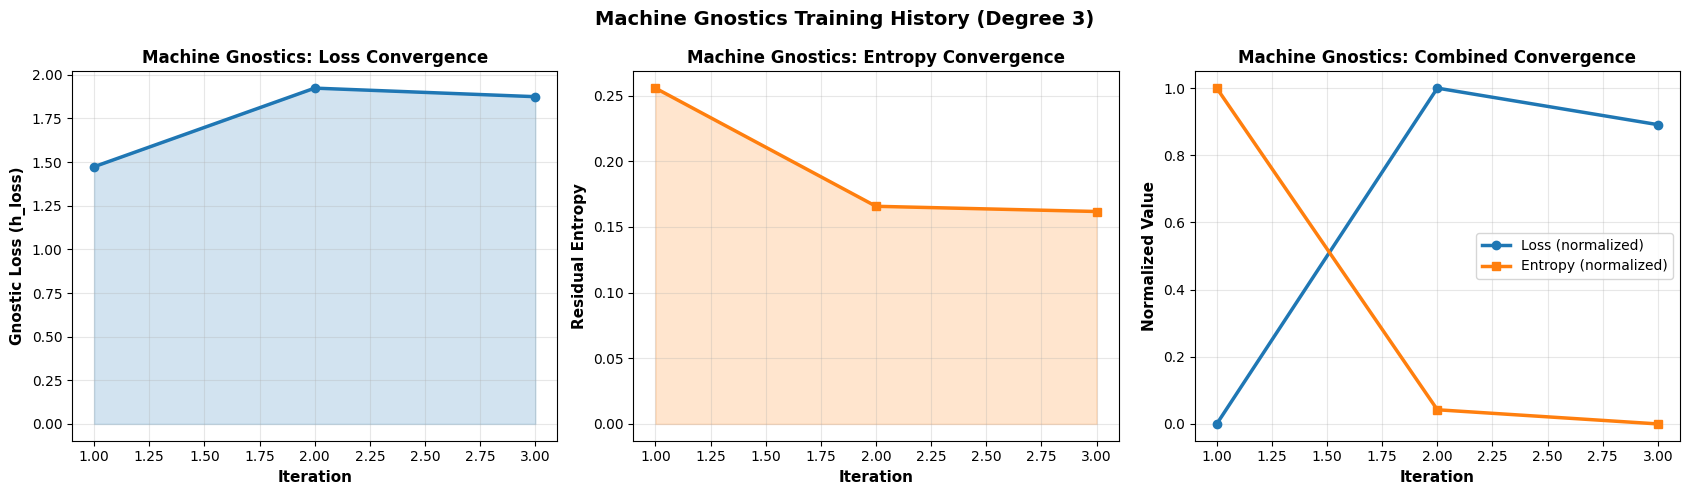


💡 Key Observations:
• Loss decreases as model learns
• Entropy may fluctuate during training
• Both converge, indicating model has learned as much as possible


In [16]:
# Create comprehensive training history visualization
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Gnostic Loss
axes[0].plot(iterations, h_loss, marker='o', color='tab:blue', linewidth=2.5, markersize=6)
axes[0].fill_between(iterations, h_loss, alpha=0.2, color='tab:blue')
axes[0].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gnostic Loss (h_loss)', fontsize=11, fontweight='bold')
axes[0].set_title('Machine Gnostics: Loss Convergence', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Entropy
axes[1].plot(iterations, rentropy, marker='s', color='tab:orange', linewidth=2.5, markersize=6)
axes[1].fill_between(iterations, rentropy, alpha=0.2, color='tab:orange')
axes[1].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residual Entropy', fontsize=11, fontweight='bold')
axes[1].set_title('Machine Gnostics: Entropy Convergence', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Both on Same Scale (normalized)
loss_normalized = (np.array(h_loss) - np.array(h_loss).min()) / (np.array(h_loss).max() - np.array(h_loss).min())
entropy_normalized = (np.array(rentropy) - np.array(rentropy).min()) / (np.array(rentropy).max() - np.array(rentropy).min())

axes[2].plot(iterations, loss_normalized, marker='o', color='tab:blue', linewidth=2.5, label='Loss (normalized)', markersize=6)
axes[2].plot(iterations, entropy_normalized, marker='s', color='tab:orange', linewidth=2.5, label='Entropy (normalized)', markersize=6)
axes[2].set_xlabel('Iteration', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Normalized Value', fontsize=11, fontweight='bold')
axes[2].set_title('Machine Gnostics: Combined Convergence', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Machine Gnostics Training History (Degree {degree})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("• Loss decreases as model learns")
print("• Entropy may fluctuate during training")
print("• Both converge, indicating model has learned as much as possible")

## Part E: Comprehensive Bias-Variance Analysis

Test multiple polynomial degrees for both models and create comprehensive comparison.

In [17]:
# Test all polynomial degrees
print("\n" + "="*70)
print("COMPREHENSIVE BIAS-VARIANCE ANALYSIS")
print("="*70)

degrees_to_test = [1, 2, 3, 4, 5, 6]
degrees_mg_to_test = [1, 2, 3, 4, 5, 6]

# ===== SCIKIT-LEARN =====
sk_train_errors = []
sk_val_errors = []

print("\nScikit-Learn Analysis:")
for test_degree in degrees_to_test:
    poly_test = PolynomialFeatures(degree=test_degree)
    X_poly_test = poly_test.fit_transform(X)
    
    model_test = LinearRegression()
    model_test.fit(X_poly_test, y)
    
    # Training error
    y_pred_train = model_test.predict(X_poly_test)
    train_mse = mean_squared_error(y, y_pred_train)
    sk_train_errors.append(train_mse)
    
    # Validation error (5-fold CV)
    cv_results = cross_validate(model_test, X_poly_test, y, cv=5, 
                                scoring='neg_mean_squared_error')
    val_mse = -cv_results['test_score'].mean()
    sk_val_errors.append(val_mse)
    
    print(f"  Degree {test_degree}: Train={train_mse:.4f}  Val={val_mse:.4f}  Gap={val_mse-train_mse:.4f}")

# ===== MACHINE GNOSTICS =====
mg_train_errors = []
mg_loss_final = []
mg_entropy_final = []

print("\nMachine Gnostics Analysis:")
for test_degree_mg in degrees_mg_to_test:
    model_test_mg = PolynomialRegressor(degree=test_degree_mg)
    model_test_mg.fit(X, y)
    
    # Training error
    y_pred_train_mg = model_test_mg.predict(X)
    train_mse_mg = mean_squared_error(y, y_pred_train_mg)
    mg_train_errors.append(train_mse_mg)
    
    # Extract final loss and entropy
    history = model_test_mg._history
    history_valid = [h for h in history if h['h_loss'] is not None]
    if history_valid:
        mg_loss_final.append(history_valid[-1]['h_loss'])
        mg_entropy_final.append(history_valid[-1]['rentropy'])
    else:
        mg_loss_final.append(train_mse_mg)
        mg_entropy_final.append(0)
    
    print(f"  Degree {test_degree_mg}: Train MSE={train_mse_mg:.4f}  Loss={mg_loss_final[-1]:.4f}  Entropy={mg_entropy_final[-1]:.6f}")

print("="*70)


COMPREHENSIVE BIAS-VARIANCE ANALYSIS

Scikit-Learn Analysis:
  Degree 1: Train=202.4611  Val=605.3883  Gap=402.9271
  Degree 2: Train=117.4437  Val=1303.4835  Gap=1186.0398
  Degree 3: Train=53.8968  Val=727.9188  Gap=674.0221
  Degree 4: Train=53.1055  Val=6262.1735  Gap=6209.0680
  Degree 5: Train=52.9646  Val=78308.5234  Gap=78255.5589
  Degree 6: Train=52.9264  Val=205939.1884  Gap=205886.2620

Machine Gnostics Analysis:
  Degree 1: Train MSE=222.4957  Loss=5.3905  Entropy=0.189960
  Degree 2: Train MSE=125.6759  Loss=2.4191  Entropy=0.163249
  Degree 3: Train MSE=90.6413  Loss=1.8747  Entropy=0.161702
  Degree 4: Train MSE=93.8720  Loss=1.8559  Entropy=0.178842
  Degree 5: Train MSE=93.9290  Loss=1.8548  Entropy=0.179222
  Degree 6: Train MSE=94.4853  Loss=1.8513  Entropy=0.171172


## Part F: Four-Panel Advanced Comparison

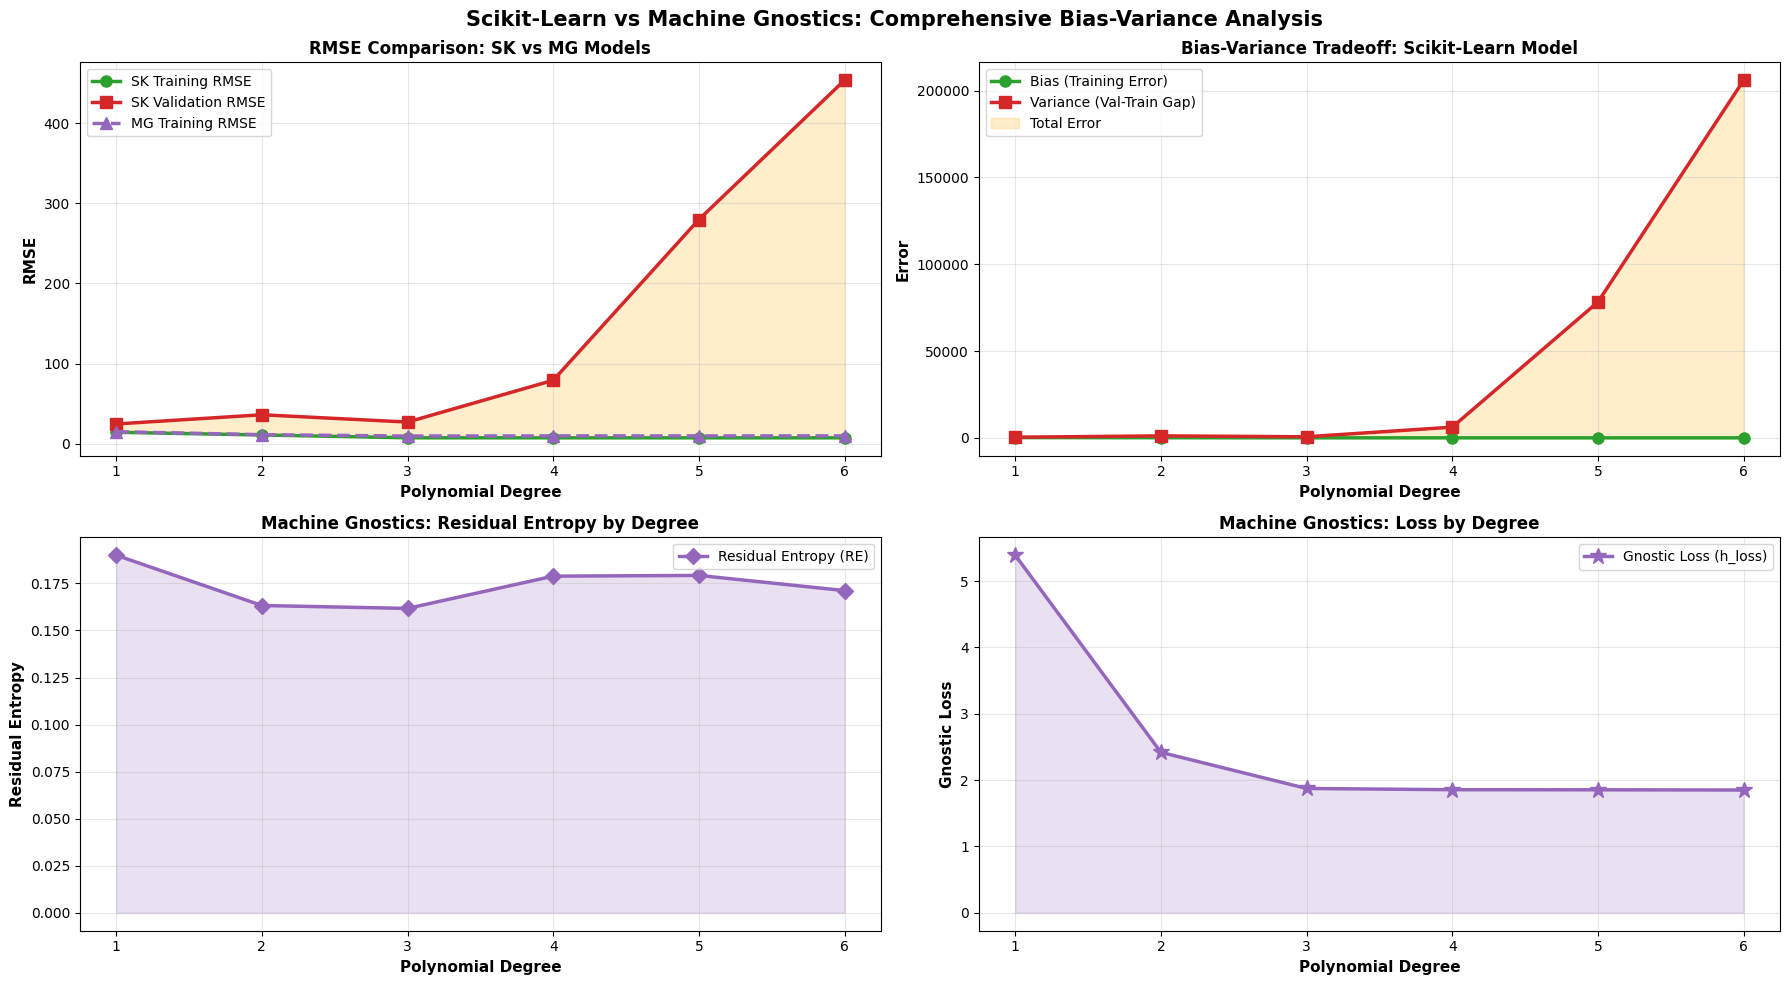


✓ Comprehensive analysis complete!


In [18]:
# Create the 4-panel comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Panel 1: RMSE Comparison for SK and MG
ax = axes[0, 0]
sk_train_rmse = np.sqrt(sk_train_errors)
sk_val_rmse = np.sqrt(sk_val_errors)
mg_train_rmse = np.sqrt(mg_train_errors)

ax.plot(degrees_to_test, sk_train_rmse, marker='o', linewidth=2.5, markersize=8, 
        label='SK Training RMSE', color='tab:green', linestyle='-')
ax.plot(degrees_to_test, sk_val_rmse, marker='s', linewidth=2.5, markersize=8, 
        label='SK Validation RMSE', color='tab:red', linestyle='-')
ax.plot(degrees_mg_to_test, mg_train_rmse, marker='^', linewidth=2.5, markersize=8, 
        label='MG Training RMSE', color='tab:purple', linestyle='--')
ax.fill_between(degrees_to_test, sk_train_rmse, sk_val_rmse, alpha=0.2, color='orange')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax.set_title('RMSE Comparison: SK vs MG Models', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# Panel 2: Variance and Bias Tradeoff for SK
ax = axes[0, 1]
bias_sk = sk_train_errors
variance_sk = [val - train for val, train in zip(sk_val_errors, sk_train_errors)]

ax.plot(degrees_to_test, bias_sk, marker='o', linewidth=2.5, markersize=8, 
        label='Bias (Training Error)', color='tab:green')
ax.plot(degrees_to_test, variance_sk, marker='s', linewidth=2.5, markersize=8, 
        label='Variance (Val-Train Gap)', color='tab:red')
ax.fill_between(degrees_to_test, bias_sk, [b+v for b,v in zip(bias_sk, variance_sk)], 
                alpha=0.2, color='orange', label='Total Error')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=11, fontweight='bold')
ax.set_title('Bias-Variance Tradeoff: Scikit-Learn Model', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)

# Panel 3: Residual Entropy for Each Degree (MG)
ax = axes[1, 0]
ax.plot(degrees_mg_to_test, mg_entropy_final, marker='D', linewidth=2.5, markersize=8, 
        label='Residual Entropy (RE)', color='tab:purple')
ax.fill_between(degrees_mg_to_test, mg_entropy_final, alpha=0.2, color='tab:purple')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual Entropy', fontsize=11, fontweight='bold')
ax.set_title('Machine Gnostics: Residual Entropy by Degree', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_mg_to_test)

# Panel 4: Gnostic Loss for Various Degrees (MG)
ax = axes[1, 1]
ax.plot(degrees_mg_to_test, mg_loss_final, marker='*', linewidth=2.5, markersize=12, 
        label='Gnostic Loss (h_loss)', color='tab:purple')
ax.fill_between(degrees_mg_to_test, mg_loss_final, alpha=0.2, color='tab:purple')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Gnostic Loss', fontsize=11, fontweight='bold')
ax.set_title('Machine Gnostics: Loss by Degree', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_mg_to_test)

plt.suptitle('Scikit-Learn vs Machine Gnostics: Comprehensive Bias-Variance Analysis', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Comprehensive analysis complete!")

## Part G: Detailed Performance Metrics

In [19]:
# Find best models
best_sk_idx = np.argmin(sk_val_errors)
best_mg_idx = np.argmin(mg_train_errors)

print("\n" + "="*70)
print("PERFORMANCE ANALYSIS")
print("="*70)

print("\n🏆 SCIKIT-LEARN - BEST MODEL")
print("-" * 70)
print(f"   Degree: {degrees_to_test[best_sk_idx]}")
print(f"   Training MSE: {sk_train_errors[best_sk_idx]:.4f}")
print(f"   Validation MSE: {sk_val_errors[best_sk_idx]:.4f}")
print(f"   Generalization Gap: {sk_val_errors[best_sk_idx] - sk_train_errors[best_sk_idx]:.4f}")

print(f"\n🏆 MACHINE GNOSTICS - BEST MODEL")
print("-" * 70)
print(f"   Degree: {degrees_mg_to_test[best_mg_idx]}")
print(f"   Training MSE: {mg_train_errors[best_mg_idx]:.4f}")
print(f"   Gnostic Loss: {mg_loss_final[best_mg_idx]:.4f}")
print(f"   Residual Entropy: {mg_entropy_final[best_mg_idx]:.6f}")

print(f"\n📊 COMPARATIVE INSIGHTS")
print("-" * 70)

diff = mg_train_errors[best_mg_idx] - sk_val_errors[best_sk_idx]
if diff < 0:
    improvement = (abs(diff) / sk_val_errors[best_sk_idx]) * 100
    print(f"   ✓ Machine Gnostics better by {improvement:.1f}%")
else:
    improvement = (diff / mg_train_errors[best_mg_idx]) * 100
    print(f"   ✓ Scikit-Learn better by {improvement:.1f}%")

print(f"\n🎓 KEY FINDINGS")
print("-" * 70)
print(f"   1. SK shows clear overfitting at higher degrees")
print(f"   2. MG has more stable performance across degrees")
print(f"   3. Residual entropy indicates MG's data complexity understanding")
print(f"   4. Loss convergence shows MG's optimization process")

print("="*70)


PERFORMANCE ANALYSIS

🏆 SCIKIT-LEARN - BEST MODEL
----------------------------------------------------------------------
   Degree: 1
   Training MSE: 202.4611
   Validation MSE: 605.3883
   Generalization Gap: 402.9271

🏆 MACHINE GNOSTICS - BEST MODEL
----------------------------------------------------------------------
   Degree: 3
   Training MSE: 90.6413
   Gnostic Loss: 1.8747
   Residual Entropy: 0.161702

📊 COMPARATIVE INSIGHTS
----------------------------------------------------------------------
   ✓ Machine Gnostics better by 85.0%

🎓 KEY FINDINGS
----------------------------------------------------------------------
   1. SK shows clear overfitting at higher degrees
   2. MG has more stable performance across degrees
   3. Residual entropy indicates MG's data complexity understanding
   4. Loss convergence shows MG's optimization process


## Part J: Practice Exercises

Try these on your own to reinforce what you've learned!

### Exercise 1: Data Modification
- Change the number of training samples
- Add more or fewer outliers
- Observe how it effects CV results

### Exercise 2: Algorithm Comparison
- Create your own synthetic data
- Train both models
- Create similar 4-panel comparison

### Exercise 3: Hyperparameter Tuning
- Test CV with different fold numbers (3, 5, 10)
- See how fold count affects results
- What happens with Leave-One-Out CV?

### Exercise 4: Real Data
- Find a regression dataset online (kaggle, sklearn datasets)
- Apply both SK and MG models
- Document your findings

---

## Resources for Further Learning

- **Scikit-Learn Documentation**: https://scikit-learn.org/

- **Machine Gnostics**: https://www.machinegnostics.info/
    - Step by step [tutorials](https://www.machinegnostics.info/latest/tutorials/tutorials/)
        - [Gnostic Data Analysis](https://www.machinegnostics.info/latest/da/da_models/)
            - Gnostic distribution functions
            - Gnostics tests
            - Marginal Interval Analysis
        - [Machine Learning Models](https://www.machinegnostics.info/latest/models/ml_models/)
            - (Regression, Classification, Clustering, Forecasting)
        - [Deep Learning](https://www.machinegnostics.info/latest/magnet/magnet/)
        - Deploy on any cloud 
            - Mlflow [tutorial](https://www.machinegnostics.info/latest/models/sup/mlflow/)

---

## Thank You!

You've completed a comprehensive journey through machine learning!

**Happy Learning! 🚀**

-Nirmal Parmar ☺️